In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

پروفایل = pd.read_excel('../data/processed/پروفایل_دانشجو.xlsx')
df = pd.read_excel('../data/raw/main.xlsx')

print("Ready!")

Ready!


In [13]:
#پاکسازی دیتای نمره
def Score_conversion(x):
    try:
        return float(x)
    except:
        return None

df['نمره_عددی'] = df['نمره'].apply(Score_conversion)

In [14]:
print(df.columns)


Index(['کدترم امتحان', 'شماره‌دانشجويي', 'کد‌ترم‌ورود دانشجو', 'درس', 'کددرس',
       'نمره', 'نوع‌نمره', 'کد‌گروه‌درسي', 'کدملي‌مدرس', 'نام‌مدرس',
       'وضعيت‌ترم‌دانشجو', 'شناسه‌دانشكده', 'نمره_عددی'],
      dtype='object')


In [15]:
# فیلتر فقط نمرات زیر ده
مردودی = df[df['نمره_عددی'] < 10]

# هر درس چند مردودی داره
مردودی_درس = مردودی.groupby('درس')['نمره_عددی'].count()

# مرتب کن از بیشتر به کمتر
مردودی_درس = مردودی_درس.sort_values(ascending=False)

print(مردودی_درس.head(20))

درس
رياضي عمومي                        971
زبان خارجي                         468
فيزيك مكانيك                       454
رياضي عمومي 1                      398
زبان فني                           377
انديشه اسلامي(1)  (مبدأ و معاد)    346
زبان  فارسي                        320
استاتيك                            250
اخلاق اسلامي (مباني و مفاهيم)      246
كارآفريني                          221
دانش خانواده و جمعيت               214
تحليل مدارهاي الكتريكي DC          211
رياضي كاربردي                      202
برنامه‌سازي پيشرفته                198
هيدروليك و نيوماتيك و آزمايشگاه    186
فيزيك حرارت                        170
تحليل مدارهاي الكتريكي AC          165
حسابداري شركت‌ها (1)               159
مباني ساختمان گسسته                158
سيستم‌عامل                         148
Name: نمره_عددی, dtype: int64


In [ ]:
# فیلتر کردن فاقد برگه ها
فاقد_برگه = df[df['نمره'] == 'فاقد برگه']

# بشمار هر درس چند فاقد برگه داره
فاقد_برگه_درس = فاقد_برگه.groupby('درس')['نمره'].count()

# مرتب کن
فاقد_برگه_درس = فاقد_برگه_درس.sort_values(ascending=False)

print(فاقد_برگه_درس.head(20))

درس
زبان خارجي                         329
زبان  فارسي                        294
تربيت بدني                         271
رياضي عمومي                        206
كارآفريني                          173
آيين زندگي (اخلاق كاربردي)         173
كارآموزي                           168
دانش خانواده و جمعيت               158
انديشه اسلامي(1)  (مبدأ و معاد)    138
زبان فني                           136
فيزيك مكانيك                       115
پرسپكتيو                           105
اخلاق اسلامي (مباني و مفاهيم)       78
رياضي كاربردي                       77
برنامه‌سازي پيشرفته                 77
آمار و احتمالات                     74
سيستم‌عامل                          72
زبان تخصصي                          70
پروژه                               67
آزمايشگاه نرم‌افزارهاي اداري        65
Name: نمره, dtype: int64


In [26]:
profile = pd.read_excel('../data/processed/پروفایل_دانشجو.xlsx')

In [28]:
# ادغام df با پروفایل
df_labeled = df.merge(
    profile[['شماره‌دانشجويي', 'در_معرض_خطر']], 
    on='شماره‌دانشجويي'
)

# فقط دانشجویان در معرض خطر
at_risk = df_labeled[df_labeled['در_معرض_خطر'] == 1]

# مردودی‌های این گروه
failed = at_risk[at_risk['نمره_عددی'] < 10]
failed.groupby('درس')['نمره_عددی'].count().sort_values(ascending=False).head(15)


درس
رياضي عمومي                        693
فيزيك مكانيك                       355
زبان خارجي                         353
رياضي عمومي 1                      298
زبان فني                           293
انديشه اسلامي(1)  (مبدأ و معاد)    286
زبان  فارسي                        266
اخلاق اسلامي (مباني و مفاهيم)      197
استاتيك                            191
تحليل مدارهاي الكتريكي DC          175
دانش خانواده و جمعيت               175
برنامه‌سازي پيشرفته                159
كارآفريني                          157
هيدروليك و نيوماتيك و آزمايشگاه    155
فيزيك حرارت                        144
Name: نمره_عددی, dtype: int64

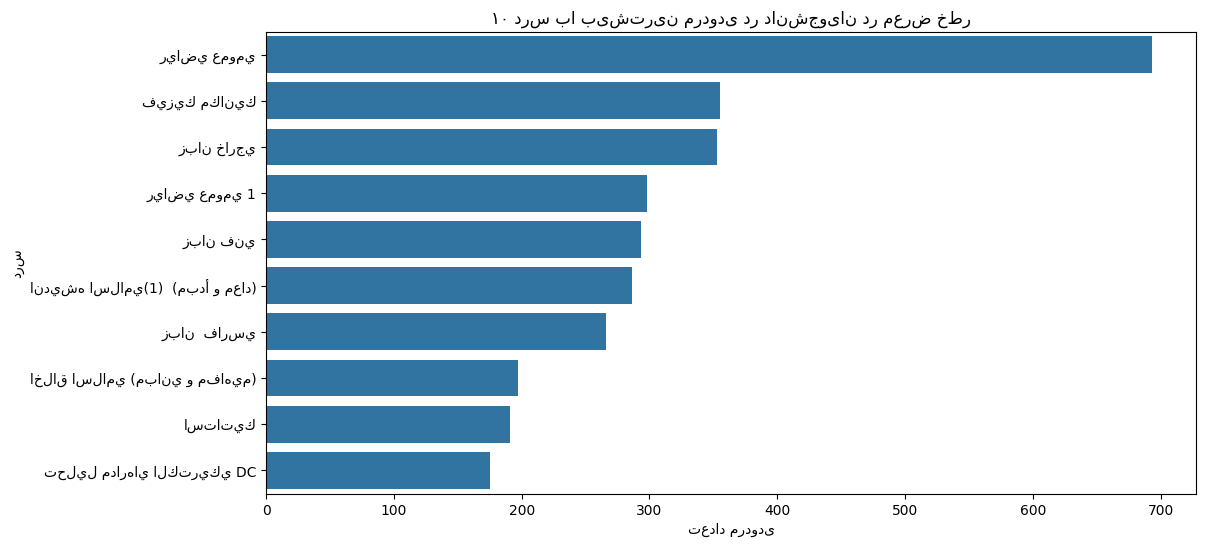

In [29]:
top_failed = failed.groupby('درس')['نمره_عددی'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_failed.values, y=top_failed.index)
plt.title('۱۰ درس با بیشترین مردودی در دانشجویان در معرض خطر')
plt.xlabel('تعداد مردودی')
plt.show()

In [ ]:
# میانگین نمره هر استاد
teacher_avg = df.groupby('نام‌مدرس')['نمره_عددی'].agg(
    میانگین='mean',
    تعداد_درس='count'
).reset_index()

# فقط اساتید با تعداد نمره بیشتر از 50
teacher_avg = teacher_avg[teacher_avg['تعداد_درس'] >= 50]

# مرتب کن
teacher_avg = teacher_avg.sort_values('میانگین', ascending=False)

print("بهترین میانگین نمره:")
print(teacher_avg.head(10))

print("\nپایین‌ترین میانگین نمره:")
print(teacher_avg.tail(10))

بهترین میانگین نمره:
                  نام‌مدرس    میانگین  تعداد_درس
18            احمد حمزه لو  19.898305         59
500         معصومه ذوالقدر  19.667808        146
169  زهرا تاج احمدي تبريزي  19.638889        225
187            زهرا نوروزي  19.597403         77
3                 آرش نجفي  19.558140        129
105              حسن كردلو  19.490196         51
305    عاطفه غلامي ملكرودي  19.287921        178
469      مرضيه سادات موسوي  19.245794        535
186             زهرا نصيري  19.240108        278
277      سيده هاجر افتخاري  19.202532         79

پایین‌ترین میانگین نمره:
                  نام‌مدرس    میانگین  تعداد_درس
22     احمد موري زاده خاكي  10.440678         59
413      محسن طاهري قزويني  10.242794        451
319         علي اكبر رحمني  10.070258        427
444          محمدرضا حسيني   9.963699         73
126        حميد گلچين دوست   9.830000        100
216            سجاد حسنوند   9.802614        153
590  نعمت اله طالشي انبوهي   9.658088        544
70              امين ر

In [31]:
low_teachers = ['ناصر بغدادي', 'نعمت اله طالشي انبوهي', 'امين رحيمي']

df[df['نام‌مدرس'].isin(low_teachers)].groupby(
    ['نام‌مدرس', 'درس']
)['نمره_عددی'].mean().round(1)

نام‌مدرس               درس                
امين رحيمي             رياضي عمومي             9.2
                       رياضي عمومي 1           8.6
                       رياضي عمومي 2           8.3
                       رياضي كاربردي          13.4
                       رياضي مهندسي           10.2
                       رياضيات مهندسي         13.2
ناصر بغدادي            آمار و احتمالات        11.3
                       رياضي عمومي             8.7
                       رياضي عمومي 1           8.4
                       رياضي عمومي 2           8.7
                       رياضي مهندسي           11.8
                       رياضي گسسته             9.8
                       مباني ساختمان گسسته    10.8
                       معادلات ديفرانسيل       6.8
نعمت اله طالشي انبوهي  آمار و احتمالات        10.1
                       رياضي عمومي             8.4
                       رياضي عمومي (2)         9.0
                       رياضي عمومي 1           9.3
                       رياضي عمومي 2   